In [3]:
import pandas as pd
import numpy as np

df = pd.read_csv(
    "../data/raw/credit_portfolio.csv"
)

df["observation_date"] = pd.to_datetime(
    df["observation_date"]
)

In [5]:
development = df[
    df["observation_date"]
    < "2023-07-01"
].copy()

validation = df[
    (
        df["observation_date"]
        >= "2023-07-01"
    )
    &
    (
        df["observation_date"]
        < "2023-10-01"
    )
].copy()

oot = df[
    df["observation_date"]
    >= "2023-10-01"
].copy()

In [6]:
print(
    "Development:",
    development.shape
)

print(
    "Validation:",
    validation.shape
)

print(
    "OOT:",
    oot.shape
)

Development: (180000, 19)
Validation: (30000, 19)
OOT: (30000, 19)


In [7]:
features = [
    "age",
    "annual_income",
    "employment_years",
    "credit_score",
    "debt_to_income",
    "credit_utilization",
    "previous_defaults",
    "delinquencies_12m",
    "loan_amount",
    "loan_term_months",
    "interest_rate",
    "unemployment_rate",
    "gdp_growth"
]

target = "default_flag"

In [8]:
X_train = development[features]
y_train = development[target]

X_val = validation[features]
y_val = validation[target]

X_oot = oot[features]
y_oot = oot[target]

In [14]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

  Using cached scikit_learn-1.9.0-cp314-cp314-win_amd64.whl.metadata (11 kB)
  Using cached scipy-1.18.0-cp314-cp314-win_amd64.whl.metadata (61 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached narwhals-2.24.0-py3-none-any.whl.metadata (15 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
Using cached scikit_learn-1.9.0-cp314-cp314-win_amd64.whl (8.3 MB)
Using cached joblib-1.5.3-py3-none-any.whl (309 kB)
Using cached narwhals-2.24.0-py3-none-any.whl (461 kB)
Using cached scipy-1.18.0-cp314-cp314-win_amd64.whl (37.3 MB)
Using cached threadpoolctl-3.6.0-py3-none-any.whl (18 kB)

   ---------------------------------------- 0/5 [threadpoolctl]
   ---------------------------------------- 0/5 [threadpoolctl]
   ---------------------------------------- 0/5 [threadpoolctl]
   ---------------------------------------- 0/5 [threadpoolctl]
   ---------------------------------------- 0/5 [threadpoolctl]
   -------------------------------------


[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [15]:
numeric_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="median"
            )
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)

In [17]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            numeric_pipeline,
            features
        )
    ]
)

In [18]:
from sklearn.linear_model import LogisticRegression

In [20]:
logistic_model = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "model",
            LogisticRegression(
                max_iter=1000,
                class_weight="balanced"
            )
        )
    ]
)

In [21]:
logistic_model.fit(X_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](13,)","['age','annual_income','employment_years',...,'interest_rate', 'unemployment_rate','gdp_growth']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,13
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passt

In [76]:
import joblib
from pathlib import Path

In [77]:
models_dir = Path("../models")

models_dir.mkdir(
    exist_ok=True
)

In [78]:
joblib.dump(
    logistic_model,
    models_dir / "pd_model.joblib"
)

['..\\models\\pd_model.joblib']

In [22]:
train_pd = (
    logistic_model
    .predict_proba(X_train)[:, 1]
)

val_pd = (
    logistic_model
    .predict_proba(X_val)[:, 1]
)

oot_pd = (
    logistic_model
    .predict_proba(X_oot)[:, 1]
)

In [24]:
pd.Series(oot_pd).describe()

count    30000.000000
mean         0.440317
std          0.165849
min          0.057679
25%          0.312843
50%          0.429412
75%          0.558063
max          0.959043
dtype: float64

In [26]:
import sys
from pathlib import Path

sys.path.append(
    str(Path.cwd().parent)
)

In [27]:
from src.validation.discrimination import (
    calculate_auc,
    calculate_ks,
    calculate_gini,
    calculate_accuracy_ratio
)

In [28]:
auc = calculate_auc(
    y_oot,
    oot_pd
)

ks = calculate_ks(
    y_oot,
    oot_pd
)

gini = calculate_gini(
    y_oot,
    oot_pd
)

accuracy_ratio = calculate_accuracy_ratio(
    y_oot,
    oot_pd
)

In [29]:
print(f"AUC: {auc:.4f}")
print(f"KS: {ks:.4f}")
print(f"Gini: {gini:.4f}")
print(
    f"Accuracy Ratio: "
    f"{accuracy_ratio:.4f}"
)

AUC: 0.6985
KS: 0.2892
Gini: 0.3970
Accuracy Ratio: 0.3970


In [30]:
validation_scorecard = pd.DataFrame({
    "Metric": [
        "AUC",
        "KS",
        "Gini",
        "Accuracy Ratio"
    ],
    "Value": [
        auc,
        ks,
        gini,
        accuracy_ratio
    ]
})

validation_scorecard

,Metric,Value
0,AUC,0.698481
1,KS,0.289243
2,Gini,0.396962
3,Accuracy Ratio,0.396962


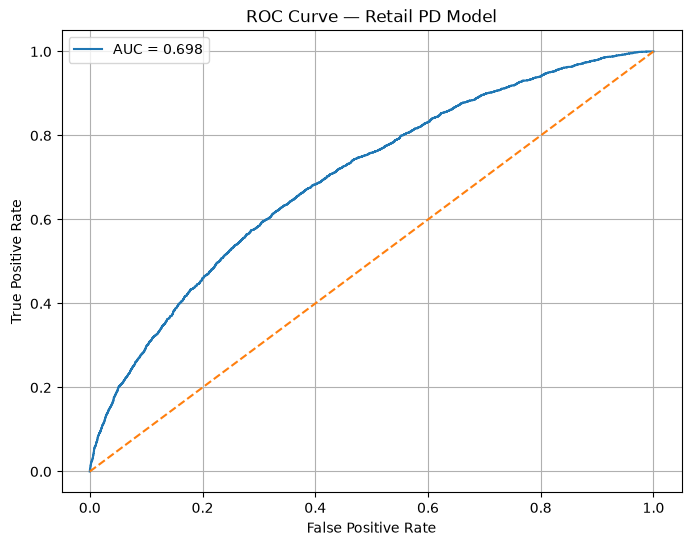

In [32]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(
    y_oot,
    oot_pd
)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    label=f"AUC = {auc:.3f}"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title(
    "ROC Curve — Retail PD Model"
)

plt.legend()
plt.grid()
plt.show()

In [33]:
from src.validation.calibration import (
    calibration_table
)

calibration = calibration_table(
    y_oot,
    oot_pd
)

calibration

,bucket,predicted_pd,realized_default_rate,observations,calibration_error
0,0,0.180499,0.023333,3000,-0.157165
1,1,0.259786,0.046000,3000,-0.213786
2,2,0.312488,0.053000,3000,-0.259488
3,3,0.359903,0.073667,3000,-0.286237
4,4,0.406519,0.074000,3000,-0.332519
5,5,0.453037,0.092333,3000,-0.360703
6,6,0.502395,0.110000,3000,-0.392395
7,7,0.558473,0.136333,3000,-0.422140
8,8,0.627279,0.171667,3000,-0.455612
9,9,0.742789,0.274667,3000,-0.468123


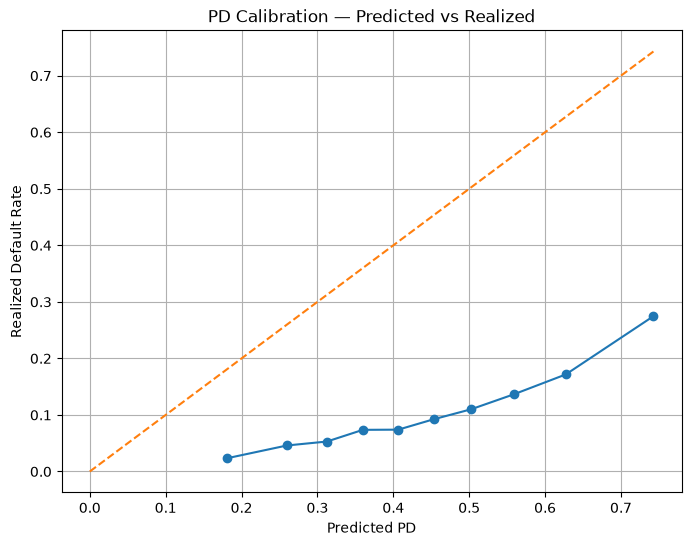

In [34]:
plt.figure(figsize=(8, 6))

plt.plot(
    calibration["predicted_pd"],
    calibration["realized_default_rate"],
    marker="o"
)

plt.plot(
    [0, calibration["predicted_pd"].max()],
    [0, calibration["predicted_pd"].max()],
    linestyle="--"
)

plt.xlabel("Predicted PD")
plt.ylabel("Realized Default Rate")

plt.title(
    "PD Calibration — Predicted vs Realized"
)

plt.grid()
plt.show()

In [35]:
from src.validation.backtesting import (
    backtest_pd
)

backtest_results = backtest_pd(
    y_oot,
    oot_pd
)

backtest_results

,bucket,predicted_pd,realized_default_rate,observations,difference
0,0,0.180499,0.023333,3000,-0.157165
1,1,0.259786,0.046000,3000,-0.213786
2,2,0.312488,0.053000,3000,-0.259488
3,3,0.359903,0.073667,3000,-0.286237
4,4,0.406519,0.074000,3000,-0.332519
5,5,0.453037,0.092333,3000,-0.360703
6,6,0.502395,0.110000,3000,-0.392395
7,7,0.558473,0.136333,3000,-0.422140
8,8,0.627279,0.171667,3000,-0.455612
9,9,0.742789,0.274667,3000,-0.468123


In [36]:
backtest_results[
    "difference"
].abs().sort_values(
    ascending=False
)

9    0.468123
8    0.455612
7    0.422140
6    0.392395
5    0.360703
4    0.332519
3    0.286237
2    0.259488
1    0.213786
0    0.157165
Name: difference, dtype: float64

In [37]:
from sklearn.ensemble import (
    RandomForestClassifier
)

In [38]:
rf_model = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "model",
            RandomForestClassifier(
                n_estimators=300,
                max_depth=6,
                min_samples_leaf=50,
                class_weight="balanced",
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

In [39]:
rf_model.fit(
    X_train,
    y_train
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](13,)","['age','annual_income','employment_years',...,'interest_rate', 'unemployment_rate','gdp_growth']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,13
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passt

In [40]:
rf_pd = (
    rf_model
    .predict_proba(X_oot)[:, 1]
)

In [41]:
rf_auc = calculate_auc(
    y_oot,
    rf_pd
)

rf_ks = calculate_ks(
    y_oot,
    rf_pd
)

rf_gini = calculate_gini(
    y_oot,
    rf_pd
)

In [42]:
comparison = pd.DataFrame({
    "Metric": [
        "AUC",
        "KS",
        "Gini"
    ],
    "Champion_Logistic": [
        auc,
        ks,
        gini
    ],
    "Challenger_RF": [
        rf_auc,
        rf_ks,
        rf_gini
    ]
})

comparison

,Metric,Champion_Logistic,Challenger_RF
0,AUC,0.698481,0.688138
1,KS,0.289243,0.278231
2,Gini,0.396962,0.376276


In [45]:
from src.validation.stability import (
    calculate_psi
)
#same for credit_score,debt_to_income,credit_utilization,loan_amount,predicted PD
annual_income_psi = calculate_psi(
    development["annual_income"],
    oot["annual_income"]
)

print(
    f"Annual Income PSI: "
    f"{annual_income_psi:.4f}"
)

Annual Income PSI: 0.0002


In [46]:
monitoring_metrics = []

for feature in [
    "credit_score",
    "annual_income",
    "debt_to_income",
    "credit_utilization",
    "loan_amount"
]:

    psi = calculate_psi(
        development[feature],
        oot[feature]
    )

    monitoring_metrics.append({
        "Feature": feature,
        "PSI": psi
    })

monitoring_df = pd.DataFrame(
    monitoring_metrics
)

monitoring_df

,Feature,PSI
0,credit_score,0.000639
1,annual_income,0.000153
2,debt_to_income,0.000403
3,credit_utilization,0.000163
4,loan_amount,0.000451


In [47]:
#testing threshold
from src.monitoring.thresholds import (
    classify_psi,
    recommended_action
)

status = classify_psi(
    credit_score_psi
)

print(status)
print(
    recommended_action(status)
)

GREEN
Continue routine monitoring.


In [48]:
from src.validation.sensitivity import (
    calculate_sensitivity
)

sensitivity = calculate_sensitivity(
    logistic_model,
    X_oot,
    "unemployment_rate",
    [1, 2, 3]
)

pd.DataFrame(sensitivity)

,feature,change,baseline_pd,stressed_pd,pd_change
0,unemployment_rate,1,0.440317,0.455921,0.015604
1,unemployment_rate,2,0.440317,0.471608,0.031292
2,unemployment_rate,3,0.440317,0.487351,0.047034


In [58]:
unemployment_sensitivity = calculate_sensitivity(
    model=logistic_model,
    data=X_oot,
    feature="unemployment_rate",
    changes=[1, 2, 3]
)

In [71]:
import yaml

from src.validation.stress_testing import (
    run_stress_test
)

In [72]:
with open(
    "../config/scenarios.yaml",
    "r"
) as file:

    scenarios = yaml.safe_load(file)

In [73]:
scenarios

{'baseline': {'unemployment_change': 0,
  'gdp_change': 0,
  'interest_rate_change': 0},
 'adverse': {'unemployment_change': 2,
  'gdp_change': -2,
  'interest_rate_change': 1},
 'severe': {'unemployment_change': 4,
  'gdp_change': -4,
  'interest_rate_change': 3}}

In [74]:
with open(
    "../config/scenarios.yaml",
    "r"
) as file:

    scenarios = yaml.safe_load(file)

In [54]:
stress_results = run_stress_test(
    model=logistic_model,
    baseline_portfolio=X_oot,
    scenarios=scenarios,
    macro_variables=macro_variables
)
stress_results.style.format({
    "avg_pd": "{:.2%}",
    "pd_change": "{:+.2%}"
})

,scenario,avg_pd,pd_change
0,Baseline,44.03%,+0.00%
1,Adverse,47.16%,+3.13%
2,Severe,50.31%,+6.28%


In [75]:
stress_results.to_csv(
    "../data/outputs/stress_results.csv",
    index=False
)

In [81]:
import pandas as pd

validation_metrics_df = pd.DataFrame({
    "metric": [
        "AUC",
        "KS",
        "Gini",
        "Accuracy Ratio"
    ],
    "value": [
        auc,
        ks,
        gini,
        accuracy_ratio
    ]
})

validation_metrics_df

,metric,value
0,AUC,0.698481
1,KS,0.289243
2,Gini,0.396962
3,Accuracy Ratio,0.396962


In [82]:
validation_metrics_df.to_csv(
    "../data/outputs/validation_metrics.csv",
    index=False
)